## Practical Mechanics & Code Execution

Uniform quantization converts high-precision floating-point numbers into low-precision integers to reduce VRAM usage and speed up memory-bandwidth-bound matrix multiplications (GEMM).

## Quantization & Dequantization Pipeline

### Floating-Point Domain (FP16 / BF16)

```text
[-12.4,  0.0,  3.2,  18.6]
         ↓
Quantization: q = round(x / S) + Z
         ↓
Integer Domain (INT8: -128 to 127)
[-85,  0,  22,  127]
         ↓
Dequantization: x_hat = S * (q - Z)
         ↓
Reconstructed Domain (FP16 / BF16)
[-12.42,  0.0,  3.21,  18.55]  ← Small quantization error
```

## Quantization Granularity Levels

### The Problem: Why Does Granularity Matter?

Imagine you are quantizing a weight matrix of size $4 \times 4$ (4 rows, 4 columns) into **INT8** (allowed values: $-128$ to $+127$).

Suppose your matrix looks like this:

$$\text{Weight Matrix } W = \begin{bmatrix}  0.1 & 0.2 & -0.1 & 0.3 \\  0.05 & -0.2 & 0.1 & 0.0 \\  \mathbf{100.0} & 0.5 & -0.4 & 0.2 \\  0.1 & 0.3 & -0.1 & 0.2  \end{bmatrix}$$

Notice row 3 has an extreme value (**$100.0$**), while rows 1, 2, and 4 have tiny values between $-0.4$ and $0.5$.

---

### 1. Per-Tensor Quantization (The "One Ruler for Everyone" Approach)

* **How it works:** You find the single maximum number in the **entire** matrix ($100.0$) and compute **1 single scale factor** $S$ for the whole matrix.
* **The Math:**

$$S = \frac{100.0}{127} \approx 0.787$$

* **What happens to small numbers?**
Take $0.1$ from Row 1. Quantized integer value:

$$q = \text{round}\left(\frac{0.1}{0.787}\right) = \text{round}(0.127) = \mathbf{0}$$

When dequantized: $0 \times 0.787 = \mathbf{0.0}$.

* **Result:** Every single row except row 3 gets turned into zeros! All fine-grained knowledge in rows 1, 2, and 4 is completely wiped out.
* **Summary:**
  - **Memory Overhead:** 1 extra float per matrix (virtually zero overhead).
  - **Accuracy:** Destroyed by outliers.

---

### 2. Per-Channel / Per-Row Quantization (The "One Ruler Per Row" Approach)

* **How it works:** Instead of forcing 1 scale on the entire matrix, you give **each row its own custom scale factor**.
* **The Math:**
  - **Row 1 Max:** $0.3 \implies S_1 = \frac{0.3}{127} = 0.00236$
  - **Row 2 Max:** $0.2 \implies S_2 = \frac{0.2}{127} = 0.00157$
  - **Row 3 Max:** $100.0 \implies S_3 = \frac{100.0}{127} = 0.787$

* **What happens to small numbers now?**
Take $0.1$ from Row 1:

$$q = \text{round}\left(\frac{0.1}{0.00236}\right) = \mathbf{42}$$

Dequantized back: $42 \times 0.00236 = \mathbf{0.0991}$ (nearly exact!).

* **Result:** Row 3's outlier ($100.0$) only affects Row 3. Rows 1, 2, and 4 keep their full precision!
* **Summary:**
  - **Memory Overhead:** 1 float per row (for a $4096 \times 4096$ matrix, that's just 4096 floats $\approx 16\text{ KB}$, negligible).
  - **Accuracy:** High for INT8 weights. This is the standard for INT8 models.

---

### 3. Group-Wise / Block-Wise Quantization (The "Sub-Divide the Row" Approach)

* **How it works:** What if a row has 4096 numbers, and *half* of that single row is small while the other half is big? Row-wise scaling still loses accuracy. So, we chop the row into small groups (e.g., $G = 128$ numbers per group) and calculate a scale factor for **each group**.
* **Example:** A row with 4096 values gets split into 32 groups of 128. That row now gets 32 scale factors!
* **Why do this?** When going down to extreme low-precision like **INT4** (where you only have 16 integer levels from $-8$ to $+7$), your quantization bins are extremely coarse. You *must* keep scale groups small ($G=128$ or $G=64$) so local numbers stay within tight bounds.
* **Summary:**
  - **Memory Overhead:** More scales stored ($\frac{1}{128}\text{th}$ extra parameters).
  - **Accuracy:** Excellent for INT4 (GPTQ, AWQ).

---

### 4. SOTA Activation Outlier Handling: LLM.int8() (The "Split Highway" Approach)

* **The Catch:** Weights are static and easy to quantize per-channel. But **activations** during inference dynamically change with user input and have sudden "outlier spikes" ($+100.0$) occurring in only 1 or 2 channels ($0.1\%$ of channels).
* **How LLM.int8() solves it:**
  1. **99.9% of channels (normal numbers):** Quantized to **INT8** and computed using fast INT8 Tensor Cores.
  2. **0.1% of channels (outliers):** Left in unquantized, high-precision **FP16**.
  3. **Final step:** Adds the two results together.

* **Summary:**
  - **Memory Overhead:** Minimal (storing 0.1% FP16 copies).
  - **Accuracy:** 100% full FP16 accuracy maintained.
  - **Runtime Speed:** Has a small switching overhead because the GPU has to run two separate execution paths.

---

### Quick Comparison Summary

| Mode | Analogy | Pros | Cons |
| --- | --- | --- | --- |
| **Per-Tensor** | One shoe size for the whole team | Zero memory overhead | One big guy ruins it for everyone |
| **Per-Channel** | One shoe size per position (Row) | High accuracy for INT8 weights | Doesn't handle dynamic activation spikes well |
| **Group-Wise** | One shoe size per group of 128 players | Essential for ultra-low precision (INT4) | Extra scale factors to store |
| **LLM.int8()** | Standard shoes for most, custom boots for giants | Zero accuracy loss on >6.7B models | Extra GPU routing overhead |

In [4]:
# --- Standalone Verification Suite ---
if __name__ == "__main__":
    print("Executing Quantization Verification Suite...")

    # 1. Test Quantizer Reconstruction
    raw_weights = torch.randn(256, 512) * 2.0
    qweight, scale = Quantizer.quantize_symmetric(
        raw_weights, num_bits=8, per_channel=True
    )
    reconstructed = Quantizer.dequantize_symmetric(qweight, scale)
    mae = torch.mean(torch.abs(raw_weights - reconstructed)).item()
    print(f"[Quantizer Test] Mean Absolute Error: {mae:.4f}")

    # 2. Test Outlier Linear Layer Execution
    layer = LLMInt8Linear(in_features=512, out_features=256, threshold=6.0)
    layer.pack_weights(raw_weights[:256, :512])

    # Inject artificial activation outliers (> 6.0) into specific channels
    input_tensor = torch.randn(2, 16, 512)
    input_tensor[:, :, 10] = 50.0  # Channel 10 outlier
    input_tensor[:, :, 100] = -80.0  # Channel 100 outlier

    out = layer(input_tensor)
    print(f"[LLM.int8 Test] Output Shape: {out.shape}")
    print("Verification Successful!")

Executing Quantization Verification Suite...
[Quantizer Test] Mean Absolute Error: 0.0127
[LLM.int8 Test] Output Shape: torch.Size([2, 16, 256])
Verification Successful!


## Inspecting Quantization Reconstruction Error

### Visual Comparison

```text
FP16 Original Tensor
┌────────────────────┐
│  0.12   4.51  -1.20│
│ 12.00   0.05   0.88│
└────────────────────┘

INT8 Quantized + Dequantized
┌──────────────────────────┐
│  0.11   4.50      -1.22  │
│ 12.00   0.04       0.86  │
└──────────────────────────┘

Absolute Error Map
┌────────────────────┐
│ 0.01   0.01   0.02 │
│ 0.00   0.01   0.02 │
└────────────────────┘
```

Diagnostic plot saved to quantization_error_comparison.png


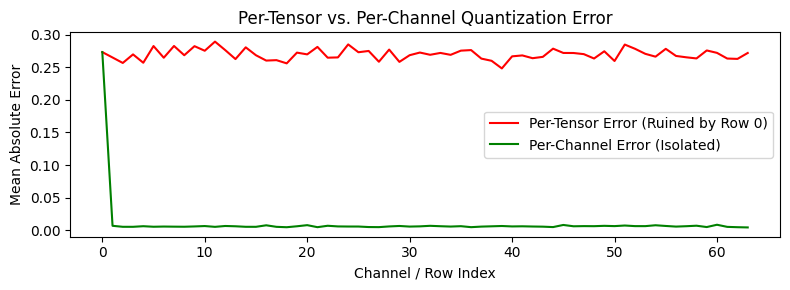

In [5]:
import matplotlib.pyplot as plt
import torch

# Generate synthetic weights with an extreme row outlier
weights = torch.randn(64, 256)
weights[0, :] *= 50.0  # Row 0 outlier

# Per-Tensor Quantization
scale_pt = torch.max(torch.abs(weights)) / 127.0
deq_pt = torch.clamp(torch.round(weights / scale_pt), -128, 127) * scale_pt

# Per-Channel Quantization
scale_pc = (
    torch.max(torch.abs(weights), dim=1, keepdim=True).values / 127.0
)
deq_pc = torch.clamp(torch.round(weights / scale_pc), -128, 127) * scale_pc

# Plot Error Comparison
err_pt = torch.abs(weights - deq_pt).mean(dim=1).numpy()
err_pc = torch.abs(weights - deq_pc).mean(dim=1).numpy()

plt.figure(figsize=(8, 3))
plt.plot(err_pt, label="Per-Tensor Error (Ruined by Row 0)", color="red")
plt.plot(err_pc, label="Per-Channel Error (Isolated)", color="green")
plt.xlabel("Channel / Row Index")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.title("Per-Tensor vs. Per-Channel Quantization Error")
plt.tight_layout()
plt.savefig("quantization_error_comparison.png")
print("Diagnostic plot saved to quantization_error_comparison.png")